In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd

pd.set_option("display.max_columns", None)

In [3]:
from pathlib import Path

lights = pd.read_csv(
    Path("../data/raw/streetlight_complaints.csv")
)

crime = pd.read_csv(
    Path("../data/raw/nypd_crime.csv")
)

In [4]:
print("LIGHT DATASET")
print("=" * 50)

print("Rows:", len(lights))
print("Columns:", len(lights.columns))

lights.info()

LIGHT DATASET
Rows: 218733
Columns: 44
<class 'pandas.DataFrame'>
RangeIndex: 218733 entries, 0 to 218732
Data columns (total 44 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   unique_key                      218733 non-null  int64  
 1   created_date                    218733 non-null  str    
 2   closed_date                     211716 non-null  str    
 3   agency                          218733 non-null  str    
 4   agency_name                     218733 non-null  str    
 5   complaint_type                  218733 non-null  str    
 6   descriptor                      218733 non-null  str    
 7   descriptor_2                    218733 non-null  str    
 8   location_type                   0 non-null       float64
 9   incident_zip                    183838 non-null  float64
 10  incident_address                85705 non-null   str    
 11  street_name                     85631 non-null   s

In [5]:
lights.columns.tolist()

['unique_key',
 'created_date',
 'closed_date',
 'agency',
 'agency_name',
 'complaint_type',
 'descriptor',
 'descriptor_2',
 'location_type',
 'incident_zip',
 'incident_address',
 'street_name',
 'cross_street_1',
 'cross_street_2',
 'intersection_street_1',
 'intersection_street_2',
 'address_type',
 'city',
 'landmark',
 'facility_type',
 'status',
 'due_date',
 'resolution_description',
 'resolution_action_updated_date',
 'community_board',
 'council_district',
 'police_precinct',
 'bbl',
 'borough',
 'x_coordinate_state_plane',
 'y_coordinate_state_plane',
 'open_data_channel_type',
 'park_facility_name',
 'park_borough',
 'vehicle_type',
 'taxi_company_borough',
 'taxi_pick_up_location',
 'bridge_highway_name',
 'bridge_highway_direction',
 'road_ramp',
 'bridge_highway_segment',
 'latitude',
 'longitude',
 'location']

In [6]:
lights[[
    "created_date",
    "closed_date",
    "latitude",
    "longitude"
]].isnull().sum()

created_date        0
closed_date      7017
latitude        36194
longitude       36194
dtype: int64

In [7]:
lights["descriptor"].value_counts(dropna=False)

descriptor
Street Light Out    218733
Name: count, dtype: int64

In [8]:
lights["borough"].value_counts(dropna=False)

borough
QUEENS           54010
BROOKLYN         50837
BRONX            49238
MANHATTAN        31190
STATEN ISLAND    21168
NaN              10830
Unspecified       1460
Name: count, dtype: int64

In [9]:
print("Earliest Created:", lights["created_date"].min())
print("Latest Created:", lights["created_date"].max())

print("Earliest Closed:", lights["closed_date"].min())
print("Latest Closed:", lights["closed_date"].max())

Earliest Created: 2020-01-01T00:45:00.000
Latest Created: 2026-09-21T00:41:00.000
Earliest Closed: 2019-12-16T11:51:00.000
Latest Closed: 2026-09-18T09:15:00.000


In [10]:
print("Latitude Min :", lights["latitude"].min())
print("Latitude Max :", lights["latitude"].max())

print("Longitude Min :", lights["longitude"].min())
print("Longitude Max :", lights["longitude"].max())

Latitude Min : 40.498948846168354
Latitude Max : 40.91246817109621
Longitude Min : -74.25495171973925
Longitude Max : -73.7008374192394


In [11]:
print("CRIME DATASET")
print("=" * 50)

print("Rows:", len(crime))
print("Columns:", len(crime.columns))

crime.info()

CRIME DATASET
Rows: 299513
Columns: 35
<class 'pandas.DataFrame'>
RangeIndex: 299513 entries, 0 to 299512
Data columns (total 35 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   cmplnt_num         299513 non-null  str    
 1   cmplnt_fr_dt       299513 non-null  str    
 2   cmplnt_fr_tm       299513 non-null  str    
 3   cmplnt_to_dt       286322 non-null  str    
 4   cmplnt_to_tm       299513 non-null  str    
 5   addr_pct_cd        299513 non-null  int64  
 6   rpt_dt             299513 non-null  str    
 7   ky_cd              299513 non-null  int64  
 8   ofns_desc          299513 non-null  str    
 9   pd_cd              299361 non-null  float64
 10  pd_desc            299513 non-null  str    
 11  crm_atpt_cptd_cd   299513 non-null  str    
 12  law_cat_cd         299513 non-null  str    
 13  boro_nm            299513 non-null  str    
 14  loc_of_occur_desc  299513 non-null  str    
 15  prem_typ_desc      2995

In [12]:
crime.columns.tolist()

['cmplnt_num',
 'cmplnt_fr_dt',
 'cmplnt_fr_tm',
 'cmplnt_to_dt',
 'cmplnt_to_tm',
 'addr_pct_cd',
 'rpt_dt',
 'ky_cd',
 'ofns_desc',
 'pd_cd',
 'pd_desc',
 'crm_atpt_cptd_cd',
 'law_cat_cd',
 'boro_nm',
 'loc_of_occur_desc',
 'prem_typ_desc',
 'juris_desc',
 'jurisdiction_code',
 'parks_nm',
 'hadevelopt',
 'housing_psa',
 'x_coord_cd',
 'y_coord_cd',
 'susp_age_group',
 'susp_race',
 'susp_sex',
 'transit_district',
 'latitude',
 'longitude',
 'lat_lon',
 'patrol_boro',
 'station_name',
 'vic_age_group',
 'vic_race',
 'vic_sex']

In [13]:
crime[[
    "cmplnt_fr_dt",
    "cmplnt_fr_tm",
    "ofns_desc",
    "law_cat_cd",
    "latitude",
    "longitude"
]].isnull().sum()

cmplnt_fr_dt    0
cmplnt_fr_tm    0
ofns_desc       0
law_cat_cd      0
latitude        0
longitude       0
dtype: int64

In [14]:
crime["law_cat_cd"].value_counts(dropna=False)

law_cat_cd
MISDEMEANOR    153488
FELONY          98506
VIOLATION       47519
Name: count, dtype: int64

In [15]:
crime["ofns_desc"].value_counts().head(30)

ofns_desc
PETIT LARCENY                      55011
HARRASSMENT 2                      44986
ASSAULT 3 & RELATED OFFENSES       31920
GRAND LARCENY                      26221
CRIMINAL MISCHIEF & RELATED OF     18466
FELONY ASSAULT                     15647
VEHICLE AND TRAFFIC LAWS           12750
MISCELLANEOUS PENAL LAW            10222
DANGEROUS DRUGS                     9088
OFF. AGNST PUB ORD SENSBLTY &       9072
ROBBERY                             8092
OTHER OFFENSES RELATED TO THEFT     7476
GRAND LARCENY OF MOTOR VEHICLE      7313
BURGLARY                            6665
SEX CRIMES                          5057
OFFENSES AGAINST PUBLIC ADMINI      4999
DANGEROUS WEAPONS                   4623
FORGERY                             3195
ADMINISTRATIVE CODE                 2264
CRIMINAL TRESPASS                   2164
OTHER STATE LAWS                    2041
INTOXICATED & IMPAIRED DRIVING      1950
THEFT-FRAUD                         1573
FRAUDS                              1456
POSSES

In [16]:
print("Earliest Crime:", crime["cmplnt_fr_dt"].min())
print("Latest Crime:", crime["cmplnt_fr_dt"].max())

Earliest Crime: 1015-09-02T00:00:00.000
Latest Crime: 2025-12-31T00:00:00.000


In [17]:
print("Latitude Min :", crime["latitude"].min())
print("Latitude Max :", crime["latitude"].max())

print("Longitude Min :", crime["longitude"].min())
print("Longitude Max :", crime["longitude"].max())

Latitude Min : 40.499625
Latitude Max : 40.912722
Longitude Min : -74.254439
Longitude Max : -73.700719


In [18]:
lights_bbox = {
    "lat_min": lights["latitude"].min(),
    "lat_max": lights["latitude"].max(),
    "lon_min": lights["longitude"].min(),
    "lon_max": lights["longitude"].max()
}

lights_bbox

{'lat_min': np.float64(40.498948846168354),
 'lat_max': np.float64(40.91246817109621),
 'lon_min': np.float64(-74.25495171973925),
 'lon_max': np.float64(-73.7008374192394)}

In [19]:
crime_bbox = {
    "lat_min": crime["latitude"].min(),
    "lat_max": crime["latitude"].max(),
    "lon_min": crime["longitude"].min(),
    "lon_max": crime["longitude"].max()
}

crime_bbox

{'lat_min': np.float64(40.499625),
 'lat_max': np.float64(40.912722),
 'lon_min': np.float64(-74.254439),
 'lon_max': np.float64(-73.700719)}

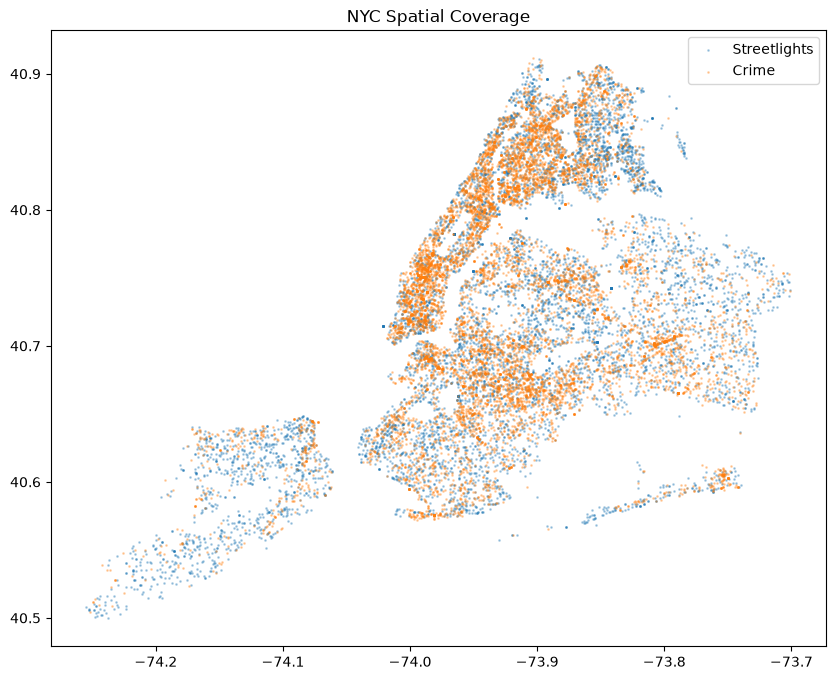

In [20]:
import matplotlib.pyplot as plt

sample_lights = lights.sample(min(10000, len(lights)))
sample_crime = crime.sample(min(10000, len(crime)))

plt.figure(figsize=(10,8))

plt.scatter(
    sample_lights["longitude"],
    sample_lights["latitude"],
    s=1,
    alpha=0.3,
    label="Streetlights"
)

plt.scatter(
    sample_crime["longitude"],
    sample_crime["latitude"],
    s=1,
    alpha=0.3,
    label="Crime"
)

plt.legend()
plt.title("NYC Spatial Coverage")
plt.show()

## Streetlight Dataset Findings

- Dataset contains streetlight-related 311 complaints.
- Key fields identified:
  - created_date
  - closed_date
  - descriptor
  - borough
  - latitude
  - longitude
- Spatial coordinates are available for geospatial analysis.
- Outage events can be isolated using descriptor = "Street Light Out".

## Crime Dataset Findings

- NYPD complaint records contain crime date and time.
- Key fields identified:
  - cmplnt_fr_dt
  - cmplnt_fr_tm
  - ofns_desc
  - law_cat_cd
  - latitude
  - longitude
- Dataset contains sufficient spatial and temporal information for causal linkage.

## Potential Data Quality Issues

- Missing coordinates may require removal.
- Missing close dates may prevent outage-duration calculation.
- Crime records with missing coordinates cannot be spatially linked.
- Coordinate bounds should be restricted to NYC during cleaning.